# ML Week 22: Odds and Ends


There are so many cool topics in the world of ML that of course it's impossible to teach all of them.

So here I very briefly introduce a few I would love to have taught in more depth.

The topics are:

* OCR
* Explainable AI in Computer Vision
* Reconstruction
* Looking at some networks together (UNet, VAE, Swin Transformers, FSTU-NET)

### Optical Character Recognition (OCR)

There are many competing standards for OCR. Here we will check out one of the most common, called tesseract (and the python implementation: pytesseract).

Let's try it on this form from a project grant:

<img src="form.png" width="400" class="center"/>

In [1]:
%pip install pytesseract pillow

Note: you may need to restart the kernel to use updated packages.


To use pytesseract you also need to install it on your computer manually here:

https://tesseract-ocr.github.io/tessdoc/Installation.html

*Note* When you install it, the path in which it is installed will show. Copy that into the below cell

In [ ]:
from PIL import Image
import pytesseract

# ADD YOUR OWN PATH HERE!
pytesseract.pytesseract.tesseract_cmd = r'C:\Users\re72fam\AppData\Local\Programs\Tesseract-OCR\tesseract.exe'

# Load image
img = Image.open("form.png")

# Run OCR
text = pytesseract.image_to_string(img)

print(text)

Titre du projet : Explorer les posshiltés de re ; ; le lez
SIGNATURES DU-DE LA PORTEUR-EUSE DE PROJET 5 anes “E &7

Je, soussigné-e, déclare sur ’honneur que les informations contenues dans cette demande sont
exactes et completes, en particulier celles relatives au plan de financement.

lieuet date: Pessac, le 24 juin 2026

Nom: Sarah Tournon-Valiente

Signature :



Sure, there are a few errors (and it really struggled with the handwritten text), but overall not too bad!

What about using it on something like a carved inscription?

(Context: Latin inscriptions at the British Museum. The ancient Greek and Roman inscriptions displayed in Room 78 show how script engraved in stone was used to record and commemorate events and transactions. You can see examples of civic or official inscriptions such as laws, decrees, treaties and accounts of income and expenditure from public funds. In the private sphere inscriptions on gravestones served to commemorate the dead. Many bear poignant epitaphs of remembrance.)

<img src="inscription.png" width="200" class="center"/>

In [19]:
# Load image
img = Image.open("inscription.png")

# Run OCR
text = pytesseract.image_to_string(img)

print(text)

BRTAEO ye TIM AEETCO
ayCusie pn Mseare

‘ag ST WSCYMCVAV 1K A
Pm XO XVSINEVELAQ
PRELLAOPEANS \

PSiES POTIVSSVBER ST ESE z
le choos gehen A “SVPER :




Okay, it's clearly struggling here. Why? Partly because tesseract tries to apply language rules. But Latin is not a language it has as a preset. So you would have to install the latin extension (https://github.com/tesseract-ocr/tessdata/blob/main/script/Latin.traineddata) to get it to perform well. But the quality of the characters may also cause problems. For this, some preprocessing with openCV (or other libraries) may help.

#### If you really need "the best of the best"

At CAA 2026 in Vienna John Wallrodt gave a talk on OCR (homepage: https://researchdirectory.uc.edu/p/wallroj)

He was tasked with digitizing 5000 hand-written index cards for corresponding archaeological objects.

After much trial and error, he found the absolute best performance was Google Cloud's "Document AI":

https://cloud.google.com/document-ai

Although not free, he was able to extract the text from all 5000 for "about 35 dollars" (if I remember correctly).



Also good according to Michael: https://www.transkribus.org/

### Interpretability in Computer Vision

Last semester we learned how some ML models (specifically ensemble methods like Random Forest) can be difficult to interpret. They are sometimes called "black boxes". This situation is even more accute when dealing with the complex and deep networks characteristic of computer vision.

However, there are some remedies. One is called "Grad-CAM" (Gradient-weighted Class Activation Mapping). In the case of classification it shows which pixesl were the most crucial in making the class decision. This is an example of Explainable AI (XAI).

It can help us check that a classifier is identifying wolves (for example) by the actual wolf as opposed to the snow in the background of the image.

In [ ]:
%pip install grad-cam

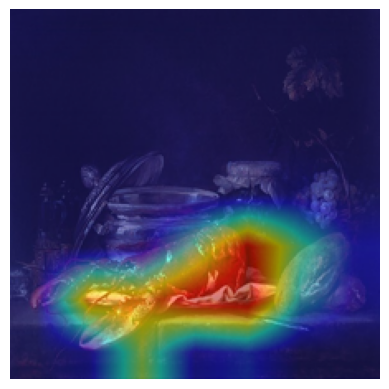

In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.eval()

# Choose target layer (this is where we check the pixel weightings to generate the heatmap)
target_layer = model.layer4[-1]

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load image and turn it into a tensor
img = Image.open("delacroix1.jpg").convert("RGB")
input_tensor = transform(img).unsqueeze(0)

# Create CAM object
    cam = GradCAM(
        model=model,
        target_layers=[target_layer]
    )

# Generate heatmap
grayscale_cam = cam(input_tensor=input_tensor)[0]

# Convert original image for plotting purposes
rgb_img = np.array(img.resize((224, 224))) / 255.0

# Overlay heatmap
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

# Display
plt.imshow(visualization)
plt.axis("off")
plt.show()

### Reconstruction

Reconstruction is often done simply by putting damaged images into LLMs with a simple prompt (ie "reconstruct this mosaic") and seeing the results. The prompt can then be adjusted to account for innacuracies. Here is an example publication:
https://arxiv.org/pdf/2210.06145

The results always need to be corroborated with domain experts.

Note: The photo below is not included online because the associated research is an LMU project that has not yet been published.

<img src="Reconstruction.png" width="600" class="center"/>

### Network Gallery

#### UNet

<img src="UNet.png" width="600" class="center"/>

#### VAE

<img src="VAE.png" width="600" class="center"/>

#### Swin (Shifted Window) Transformer

<img src="Swin.png" width="800" class="center"/>

#### FSTU (Filtered Swin Transformer U-Net) Net

Shengxiang Wang et al. 2025, FSTU-Net: A sparse-view CT reconstruction framework for enhanced imaging efficiency and quality in neutron tomography

10.1016/j.nima.2025.170524

<img src="FSTU-Net.png" width="800" class="center"/>